# Contrucción de un modelo de regresión polinomial.


La construcción del modelo polinomia dentro del contexto del problema es probar si las relaciones meteorológicas (humedad, 

presión, viento ) y la temperatura máxima son realmente lineales, o por el contrario existen patrones curvos que no se 

puedieron reconocer debido a las limitaciones del Lab 1.




Antes de iniciar la creación del modelo polinomial hay que dividir de nuevo el csv entre los datos de entrenamiento y 

datos de prueba. El csv dentro de este laboratorio ya cuenta con todas las depuraciones realizadas en la etapa de preparación 

de datos del laboratorio anterior. 


In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

df = pd.read_csv("Datos_Lab1_procesados.csv")

features = ['humedad_desv', 'humedad_min', 'dia_sin', 'dia_cos']
X = df[features]
y = df['temp_max_manana']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

En el anterior codigo se escogieron las mismas variables que se utilizaron para el modelo de regresión lineal y se separaron

las variables de prueba y entrenamiento teniendo en cuenta los mismos parametros del laboratorio anterior.


Ya con esto establecido se puede empezar con la creación del modelo de regresión polinomial.

In [ ]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, PolynomialFeatures
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GridSearchCV
import numpy as np 
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

numeric_transformer_poly = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler()),        
    ("polynomial", PolynomialFeatures()) 
])

preprocessor_poly = ColumnTransformer(transformers=[
    ("num", numeric_transformer_poly, features),
    
])

pipeline_poly = Pipeline(steps=[
    ("preprocesamiento", preprocessor_poly),
    ("modelo", LinearRegression())
])




En primer lugar se crea un pipeline llamado numeric_transformer que tiene tres pasos. El primero catalogado como "imputer"

rellena nulos con la media de esa columna, "scaler" por su parte se encarga de estandarizar cada variable, es decir le asigna

una media de 0 y desviación estandar de 1, esto es relevante para el siguiente paso ya que si no se escala antes , una 

variable con valores grandes dominará numéricamente los términos polinomiales. Por último "polynomial" genera las nuevas 

columnas las que tienen los terminos elvados y producto cruzado



Preprocessor_poly aplica el pipeline que definimos anteriormente a las cuatro variables de interés (humedad_desv, 

humedad_min, dia_sin, dia_cos). El siguiente pipeline (pipeline_only) se encarga de unir los dos anteriores, primero pasa

los datos por el ColumnTransformer (imputación --> escalado --> polinomio), y el resultado entra en el  segundo paso 

("modelo") que se encarga de crear el modelo de regresión lineal correspondiente con LinearRegression().





In [5]:
param_grid_poly = {
    "preprocesamiento__num__scaler": [StandardScaler(), MinMaxScaler()],
    "preprocesamiento__num__polynomial__degree": [1, 2, 3, 4]
}

grid_poly = GridSearchCV(
    estimator=pipeline_poly,
    param_grid=param_grid_poly,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)
grid_poly.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...egression())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'preprocesamiento__num__polynomial__degree': [1, 2, ...], 'preprocesamiento__num__scaler': [StandardScaler(), MinMaxScaler()]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for c

param_grid_poly es un diccionario que define el espacio de búsqueda es decir todas las combinaciones de configuración que se 

desea que GridSearchCV pruebe. En primer lugar se accede a la instrucción scaler y se define que aui puede ir StandarScaler()

o MinMaxScaler(). Por otro lado, se accede a la instrucción polynomial de numeric_transfer_poly la cual es la encargada de 

definir las nuevas variables y se le asigna a su parametro "degree" todos los grados posibles que se van a probar.






grid_poly se encarga de construir el objeto buscador, en el cual se ingresa el pipeline_only  al que se le va ir ingresando

todas las variables posibles y param_grid_poly como el espacio de busqueda que se definión anteriormente.

In [14]:
print("Mejor configuración:", grid_poly.best_params_)
mejor_poly = grid_poly.best_estimator_

for nombre, X_, y_ in [("train", X_train, y_train), ("test", X_test, y_test)]:
    pred = mejor_poly.predict(X_)
    print(f"--- {nombre} ---")
    print("RMSE:", np.sqrt(mean_squared_error(y_, pred)))
    print("MAE:", mean_absolute_error(y_, pred))
    print("R²:", r2_score(y_, pred))
    
    
n_coeficientes = mejor_poly.named_steps["modelo"].coef_.shape[0]
print("Número de coeficientes del modelo (grado 3):", n_coeficientes)

Mejor configuración: {'preprocesamiento__num__polynomial__degree': 3, 'preprocesamiento__num__scaler': StandardScaler()}
--- train ---
RMSE: 4.457485544501476
MAE: 3.545781400268208
R²: 0.7581596937629567
--- test ---
RMSE: 4.458764338454476
MAE: 3.5620752053306415
R²: 0.7411164343033989
Número de coeficientes del modelo (grado 3): 35


De los datos que se pueden apreciar es posible extraer varias conclusiones importantes. En primer lugar, GidSearchCV 

determinó que la mejor configuración es la que tiene grado 3 con StandardScaler(). Por otro lado se puede evidenciar que las

metricas arrojadas entre train y test son practicamente identicas. Esto es una muy buena señal ya que significa que no hay 

sobreajuste con el grado 3. Es decir, el modelo generaliza casi igual de bien a datos que nunca vio que a los datos con los 

que se entrenó.



Con respecto al modelo de regresión lineal que se elaboró el el laboratorio pasado podemos visualizar una pequeña mejoría en

las mediciones de error. El RMSE bajó de 4.54 a 4.459 lo que representa una mejora de 0.08 en MAE  subió de 3.62 a 3.562 y el 

R^2 subió de 0.731 a 0.741. Esto nos indica que la mejora es real pero no marginal. Esto puede deberse a que la variable de

dia_del_anio que presentaba una relación no lineal con la variable objetivo fue resuelta en dos : su coeficiente seno y 
 
coseno. Este cambió le dió la posibilidad al modelo de regresión lineal de capturar la curva estacional sin necesitar 

potencias adicionales.
                                                                                                                                                                    

# Generación de curvas de validación


Ya se pudo concluir que el grado 3 ganó en el GridSearchCV. Ahora es necesario visualizar como se comporta el error a medida 

que cambias el grado. Para tal propósito de hace uso de la scurvas de validación , las cuales nos van a ayudar la pregunta 

¿ En que punto se evidencia el sobreajuste?.

In [15]:
pipeline_poly.set_params(preprocesamiento__num__scaler=StandardScaler())

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocesamiento', ...), ('modelo', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output o

El primer paso es fijar el mejor escalador que como se vió antes fue el de StandardScaler(). Esto se hace debido a que las 

comparaciones se van a hacer únicamente teniendo en cuenta el grado del polinomio. 

In [16]:
from sklearn.model_selection import validation_curve

grados = [1, 2, 3, 4, 5, 6]

Se definene los grados de prueba desde el 1 hasta el 6 

In [21]:
train_scores, val_scores = validation_curve(
    estimator=pipeline_poly,
    X=X_train, y=y_train,
    param_name="preprocesamiento__num__polynomial__degree",
    param_range=grados,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

# Como el scoring viene negado, se multiplica por -1 para volver a RMSE positivo
train_rmse = -train_scores
val_rmse = -val_scores


print(train_rmse)
print(val_rmse)

[[4.55379471 4.48995143 4.56181127 4.58675457 4.49484482]
 [4.53011408 4.46771384 4.52700626 4.56163804 4.46114762]
 [4.47144134 4.42590206 4.462569   4.49448468 4.39072164]
 [4.4156154  4.36758544 4.39503018 4.42346261 4.32864571]
 [4.32777278 4.31744272 4.33365736 4.36908563 4.29062379]
 [4.2160774  4.20335424 4.23796918 4.26463072 4.17695155]]
[[ 4.48135346  4.73390043  4.45071003  4.34715119  4.71563012]
 [ 4.45177042  4.71274004  4.47637182  4.32393839  4.74026579]
 [ 4.4160307   4.61948759  4.49229486  4.36157853  4.8005397 ]
 [ 4.42375086  4.62283386  4.79851977  4.63244891  4.86653442]
 [ 4.84136927  4.64499059  4.64328639  5.0731897   5.00319045]
 [ 4.83844444  4.71119757  6.37141459 11.99632543 13.98183194]]


Ahora se ejecuta validation_curve la cual se comporta similar a la función GridSearchCV, la diferencia es que no se limita

a arrojar el mejor resultado, sino que devuelve todas las mediciones de error de train  y de validación cruzada , para cada

valor de grado. Como el scoring viene negado se debe multiplicar por menos 1 para volver cada RMSE positivo.


train_rmse y val_rmse contiene una lista que contiene otras listas que guardan los rmse calculados para cada grado. Se 

calulan  5 rmse diferentes por cada grado ya que los datos de entrenamiento se dividen en 5 partes diferentes llamdas folds

las cuales se utilizan para validación cruzada ; hay 5 rondas de medicion en el que se entrena con 4 folds y se deja 

uno para validación , en cada ronda se cambian los folds de entrenamiento y validación y cada prueba arroja su propio rmse.

In [20]:
import numpy as np

train_mean = train_rmse.mean(axis=1)
train_std  = train_rmse.std(axis=1)
val_mean   = val_rmse.mean(axis=1)
val_std    = val_rmse.std(axis=1)

for g, tm, vm in zip(grados, train_mean, val_mean):
    print(f"Grado {g}: RMSE train={tm:.3f} | RMSE val={vm:.3f}")

Grado 1: RMSE train=4.537 | RMSE val=4.546
Grado 2: RMSE train=4.510 | RMSE val=4.541
Grado 3: RMSE train=4.449 | RMSE val=4.538
Grado 4: RMSE train=4.386 | RMSE val=4.669
Grado 5: RMSE train=4.328 | RMSE val=4.841
Grado 6: RMSE train=4.220 | RMSE val=8.380


Una vez que se tiene el conjunto de errores hay que obtener su promedio y variabilidad para poder graficar posteriormente.

Cabe resaltar la diferencia entre la variable de entrenamiento y la de validación cruzada. En entrenamiento el error se 

calcula sobre los datos que  el modelo si vió, en cada ronda se entrena con 4 folds y utiliza esos mismos folds para medir

que tan bien predice el modelo. Mientras que en validación cruzada se entrena con 4 folds y se mide  su eficacia con respecto

al fold que no ha visto, esto nos muestra si el modelo aprendió el patrón real de los datos o si sólo memorizó 

particularidades de los datos de entrenamiento.






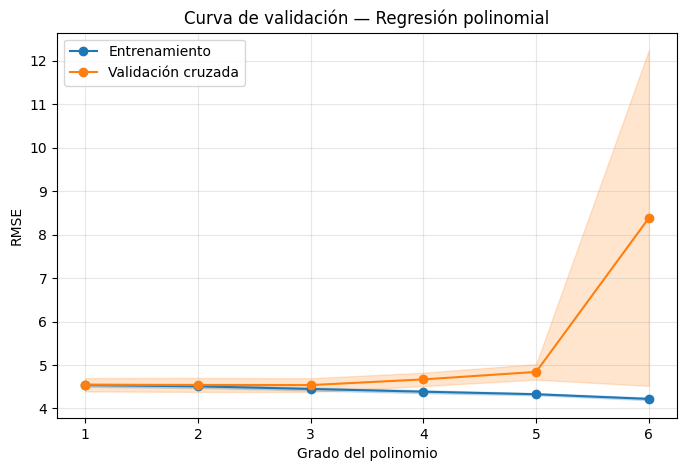

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(grados, train_mean, marker='o', label="Entrenamiento", color="tab:blue")
plt.fill_between(grados, train_mean - train_std, train_mean + train_std, alpha=0.2, color="tab:blue")

plt.plot(grados, val_mean, marker='o', label="Validación cruzada", color="tab:orange")
plt.fill_between(grados, val_mean - val_std, val_mean + val_std, alpha=0.2, color="tab:orange")

plt.xlabel("Grado del polinomio")
plt.ylabel("RMSE")
plt.title("Curva de validación — Regresión polinomial")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

La de entrenamiento (azul) baja de manera lenta y constante de 4.55 (grado 1) a 4.2(grado 6). En ningún momento se dispara

ni se comporta de manera extraña, lo cual es un comportamiento esperado , porque a medida de que aumenta el grado el modelo

tiene más flexibilidad para ajustarse a sus propios datos de entrenamiento.


Por otro lado, la linea de validación cruzada (naranja) se mantiene bastante cerca a la curva de entrenamiento entre los 

grados 1 y 3, pero a partir del grado 4 empieza a separarse y en el grado 6 se dispara a 8.4, casi el doble del error de

entrenamiento en ese mismo punto.


Esto refuerza el porque se escogió el modelo con grado 3 ya que es el punto donde el RMSE de validación cruzada todavía está

muy cerca de su mínimo antes de que la breca empieze a crecer.

In [23]:
gap = val_mean - train_mean
for g, diff in zip(grados, gap):
    print(f"Grado {g}: diferencia val-train = {diff:.3f}")

Grado 1: diferencia val-train = 0.008
Grado 2: diferencia val-train = 0.031
Grado 3: diferencia val-train = 0.089
Grado 4: diferencia val-train = 0.283
Grado 5: diferencia val-train = 0.513
Grado 6: diferencia val-train = 4.160


La brecha entre el error de entrenamiento y el de validación cruzada, que pasa de 0.008 en grado 1 a 4.16 en grado 6, 

evidencia el trade-off sesgo-varianza de forma directa. En los grados bajos 1-2 ambos errores son similares pero elevados

, señal de un sesgo alto: el modelo es demasiado simple para obtener la relación real. A partir del grado 4, la brecha crece 

de forma acelerada mientras el error de entrenamiento sigue bajando , lo que implica una alta varianza ya que el modelo 

enpieza a ajustarse al ruido especifico de cada partición de entrenamiento en lugar de encontrar el patrón. El grado 3, 

representa el  punto de mejor balance entre ambas fuentes de error, coincidiendo con el mínimo de la curva de validación 

cruzada antes de que la varianza comience a dominar.

# Construcción de modelos de regresión lineal regularizados.

En primer lugar hay que reconstruir los pipelines sin los polinomios


In [24]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import KFold

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())  # placeholder, se sobreescribe en el grid
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, features)
])

pipeline_sinreg = Pipeline([("preprocesamiento", preprocessor), ("modelo", LinearRegression())])
pipeline_ridge  = Pipeline([("preprocesamiento", preprocessor), ("modelo", Ridge())])
pipeline_lasso  = Pipeline([("preprocesamiento", preprocessor), ("modelo", Lasso(max_iter=5000))])

En este caso lo que sucede es que se vuelven a crear los pipelines para poder imputar nulos, y escalar las columnas. Pero 

adicionalmente hay pipelines que corresponen a un modelo de regresión lineal común uno con un modelo Ridge y otro con un 

modelo Lasso.

In [25]:
param_grid_ridge = {
    "preprocesamiento__num__scaler": [StandardScaler(), MinMaxScaler()],
    "modelo__alpha": [0.01, 0.1, 1, 10, 100]
}
param_grid_lasso = {
    "preprocesamiento__num__scaler": [StandardScaler(), MinMaxScaler()],
    "modelo__alpha": [0.01, 0.1, 1, 10, 100]
}

Se definen de nuevo los espacios de búsqueda, pero en vez de definir una serie de grados se define "alpha", siendo este

el grado de penalización que va tener lugar tanto en ridge como en lasso.


In [28]:


grid_ridge = GridSearchCV(pipeline_ridge, param_grid_ridge, cv=5,
                           scoring="neg_root_mean_squared_error", n_jobs=-1)
grid_lasso = GridSearchCV(pipeline_lasso, param_grid_lasso, cv=5,
                           scoring="neg_root_mean_squared_error", n_jobs=-1)

grid_ridge.fit(X_train, y_train)
grid_lasso.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step..._iter=5000))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'modelo__alpha': [0.01, 0.1, ...], 'preprocesamiento__num__scaler': [StandardScaler(), MinMaxScaler()]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"

Una vez establecidos los espacios de búsqueda se vuelve a hacer GridSearchCV para buscar que "alpha" o grado de penalización 

es el que arroja el menor error tanto como para el modelo Ridge como para Lasso.

In [30]:
param_grid_sinreg = {
    "preprocesamiento__num__scaler": [StandardScaler(), MinMaxScaler()]
}
grid_sinreg = GridSearchCV(pipeline_sinreg, param_grid_sinreg, cv=5,
                            scoring="neg_root_mean_squared_error", n_jobs=-1)
grid_sinreg.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...egression())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'preprocesamiento__num__scaler': [StandardScaler(), MinMaxScaler()]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Cont

Se establece el espacio de búsqueda para el modelo de regresión común, y se hace GridSearch sobre este .

In [31]:
resultados = {}
for nombre, grid in [("Sin regularización", grid_sinreg), ("Ridge", grid_ridge), ("Lasso", grid_lasso)]:
    modelo = grid.best_estimator_
    pred_test = modelo.predict(X_test)
    resultados[nombre] = {
        "mejor_alpha": grid.best_params_.get("modelo__alpha", "N/A"),
        "RMSE": np.sqrt(mean_squared_error(y_test, pred_test)),
        "MAE": mean_absolute_error(y_test, pred_test),
        "R2": r2_score(y_test, pred_test)
    }

import pandas as pd
pd.DataFrame(resultados).T

,mejor_alpha,RMSE,MAE,R2
Sin regularización,N/A,4.544819,3.636443,0.731027
Ridge,0.01,4.544818,3.636442,0.731027
Lasso,0.01,4.544318,3.636118,0.731086


De estos resultados es importante resaltar que los tres modelos son practicamente identicos, lo que indica que no hay ninguna

mejora real al momento de regularizar la regresión lineal. De igual manera se puede evidenciar que el mejor alpha escogido fue

0.01 para ambos casos, esto significa que el modelo sin regularizar no tenía un problema de coeficientes inflados o inestables

que requirieran ajuste.

In [32]:
coef_df = pd.DataFrame({
    "variable": features,
    "sin_regularizacion": grid_sinreg.best_estimator_.named_steps["modelo"].coef_,
    "ridge": grid_ridge.best_estimator_.named_steps["modelo"].coef_,
    "lasso": grid_lasso.best_estimator_.named_steps["modelo"].coef_
})
coef_df["lasso_es_cero"] = coef_df["lasso"] == 0
coef_df

,variable,sin_regularizacion,ridge,lasso,lasso_es_cero
0,humedad_desv,1.756026,1.756031,1.752667,False
1,humedad_min,-0.778894,-0.778903,-0.771686,False
2,dia_sin,-2.023505,-2.023495,-2.012154,False
3,dia_cos,-6.076742,-6.076701,-6.071891,False


Tal como se puede apreciar en los resultados anteriores , los coeficientes de cada una de las variables elegidas son  

consistentes entre cada modelo, lo que refuerza de nuevo la idea de que la regularización no cambión en gran medida los 

resultados del modelo. Cabe aclarar que lasso no evió ningún coeficiente a cero, lo cual es lógico debido a que el coeficiente

de penalización elegido fue el más bajo.